## ITSimplera Internship
#### AL/ ML
### Author: **Alina Bukhari**
### Reg No: **AIMLB01-1688**
### **Task: 01**

`Basic Information`

In [2]:
# Importing libraries for data analysis and visualizations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the style for all plots to make it look clean and professional
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
# Loading the data and combining both sheets
file_path = '/content/online_retail_II.xlsx'
df_2009 = pd.read_excel(file_path, sheet_name=0)
df_2010 = pd.read_excel(file_path, sheet_name=1)

df = pd.concat([df_2009, df_2010], ignore_index=True)

In [6]:
print("Sheet 1 shape:", df_2009.shape)
print("Sheet 2 shape:", df_2010.shape)
print("Combined shape:", df.shape)

Sheet 1 shape: (525461, 8)
Sheet 2 shape: (541910, 8)
Combined shape: (1067371, 8)


In [7]:
# .head() shows the first 5 rows of our combined data
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
# shape = row and cols
print(f"Shape of the data = {df.shape}")

Shape of the data = (1067371, 8)


In [9]:
# list of all cols
print(f"List of all the cols in data : {list(df.columns)}")

List of all the cols in data : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [11]:
# data types of each column in data
print(f"Data Types of cols: \n{df.dtypes}")

Data Types of cols: 
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [13]:
# for combined summary of all cols (their names, dtypes, and null count); .info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [14]:
# for statistical summary (of numerical cols) we do .describe()
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


`Missing values`

In [19]:
# isnull() states True/False for each cell,
# .sum() counts True values per column
# displays zero for col with no missing values
missing_count = df.isnull().sum()
print(missing_count)

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [20]:
# convert count to a percentage for easy interpretation
missing_percent = (missing_count / len(df)) * 100
print(missing_percent)

Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64


In [21]:
# combine both into one clean table
missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)  #rounding off to 2 dec places
})
missing_report

,Missing Count,Missing %
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [22]:
# only show columns that actually HAVE missing values,

missing_report = missing_report[missing_report['Missing Count'] > 0]
missing_report

,Missing Count,Missing %
Description,4382,0.41
Customer ID,243007,22.77


In [23]:
# sorted worst first
missing_report = missing_report.sort_values('Missing Count', ascending=False)

In [24]:
print("Columns with missing data:")
missing_report

Columns with missing data:


,Missing Count,Missing %
Customer ID,243007,22.77
Description,4382,0.41


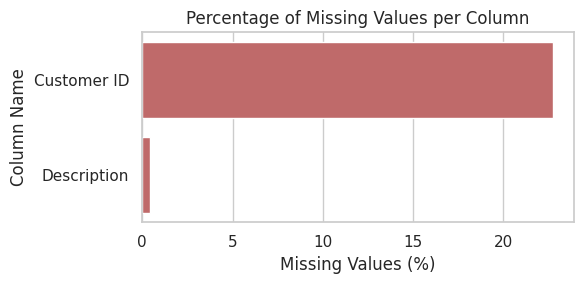

In [30]:
# Visualizing missing values via a bar chart
plt.figure(figsize=(6, 3))
sns.barplot(x=missing_report['Missing %'], y=missing_report.index, color='indianred', orient='h')
plt.title('Percentage of Missing Values per Column')   # required: title
plt.xlabel('Missing Values (%)')                        # required: x-axis label
plt.ylabel('Column Name')                                # required: y-axis label
plt.tight_layout()
plt.show()

`Duplicate rows `

In [31]:
# .duplicated() tells us rows that are IDENTICAL
# .sum() counts how many such rows exist
duplicate_count = df.duplicated().sum()

print(f"Number of fully duplicate rows: {duplicate_count}")

Number of fully duplicate rows: 34335


In [32]:
print(f"That's {duplicate_count/len(df)*100:.2f}% of the dataset")

That's 3.22% of the dataset


In [33]:
# keep=False shows BOTH copies of every duplicate pair, so you can inspect them
df[df.duplicated(keep=False)].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


`Creating Revenue Column`

In [34]:
# Revenue = how many units sold x price per unit
df['Revenue'] = df['Quantity'] * df['Price']

df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


`Top10 Best Selling Products By Quanitity`

In [35]:
# groupby('Description') groups all rows with the same product name together

# ['Quantity'].sum() adds up total quantity sold for each product

top10_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top10_qty

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,108545
WHITE HANGING HEART T-LIGHT HOLDER,93050
ASSORTED COLOUR BIRD ORNAMENT,81306
JUMBO BAG RED RETROSPOT,78090
BROCADE RING PURSE,70700
PACK OF 60 PINK PAISLEY CAKE CASES,56575
60 TEATIME FAIRY CAKE CASES,54366
SMALL POPCORN HOLDER,49616
PACK OF 72 RETROSPOT CAKE CASES,49344


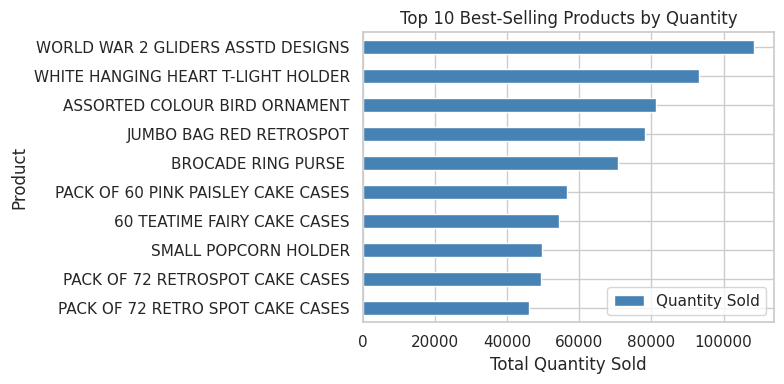

In [36]:
# Visualizing it
plt.figure(figsize=(8, 4))
top10_qty.sort_values().plot(kind='barh', color='steelblue', label='Quantity Sold')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.legend()
plt.tight_layout()
plt.show()

`Top10 Best Selling Products By Revenue`

In [37]:
top10_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top10_revenue)

Description
REGENCY CAKESTAND 3 TIER               327813.65
DOTCOM POSTAGE                         322647.47
WHITE HANGING HEART T-LIGHT HOLDER     257533.90
JUMBO BAG RED RETROSPOT                148800.64
PARTY BUNTING                          147948.50
ASSORTED COLOUR BIRD ORNAMENT          131413.85
PAPER CHAIN KIT 50'S CHRISTMAS         121662.14
POSTAGE                                112341.00
CHILLI LIGHTS                           84854.16
ROTATING SILVER ANGELS T-LIGHT HLDR     73814.72
Name: Revenue, dtype: float64


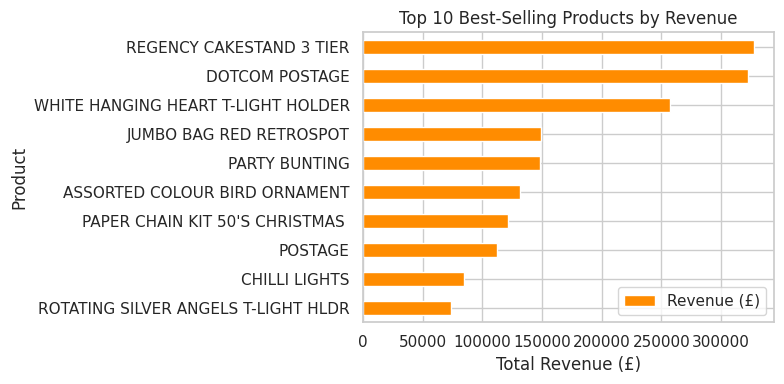

In [38]:
# Visualizing it

plt.figure(figsize=(8, 4))
top10_revenue.sort_values().plot(kind='barh', color='darkorange', label='Revenue (£)')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.legend()
plt.tight_layout()
plt.show()

`Sales performance by Country `

In [40]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_revenue

,Revenue
Country,
United Kingdom,1.638258e+07
EIRE,6.155196e+05
Netherlands,5.485249e+05
Germany,4.179886e+05
France,3.281918e+05
Australia,1.671291e+05
Switzerland,9.972876e+04
Spain,9.185948e+04
Sweden,8.780942e+04


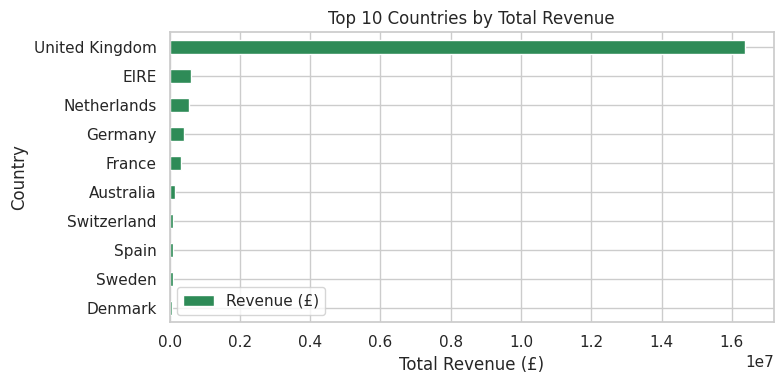

In [41]:
# Plotting it

plt.figure(figsize=(8, 4))
country_revenue.sort_values().plot(kind='barh', color='seagreen', label='Revenue (£)')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.legend()
plt.tight_layout()
plt.show()

` Revenue over time_ Monthly trend`

In [42]:
# Convert InvoiceDate from text to an actual datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['InvoiceDate'].sample(5)

,InvoiceDate
419244,2010-10-28 14:19:00
688436,2011-04-19 10:40:00
582026,2011-01-13 14:29:00
862496,2011-09-12 14:22:00
837264,2011-08-24 13:20:00


In [43]:
# Extracting only the Year-Month part (e.g., "2010-06") and round every date to the 1st of its month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

df['InvoiceMonth'].sample(5)

,InvoiceMonth
748929,2011-06-01
608519,2011-02-01
643027,2011-03-01
800971,2011-07-01
188328,2010-05-01


In [44]:
# Group by month and sum revenue
monthly_revenue = df.groupby('InvoiceMonth')['Revenue'].sum()

monthly_revenue

,Revenue
InvoiceMonth,
2009-12-01,799847.110
2010-01-01,624032.892
2010-02-01,533091.426
2010-03-01,765848.761
2010-04-01,590580.432
2010-05-01,615322.830
2010-06-01,679786.610
2010-07-01,575236.360
2010-08-01,656776.340


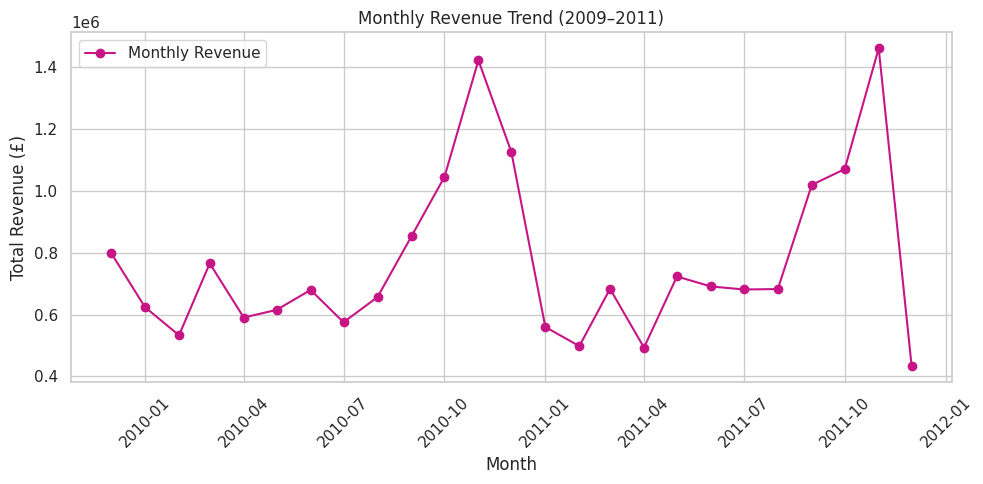

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values,
         marker='o', color='mediumvioletred', label='Monthly Revenue')
plt.title('Monthly Revenue Trend (2009–2011)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`Correlation heatmap`

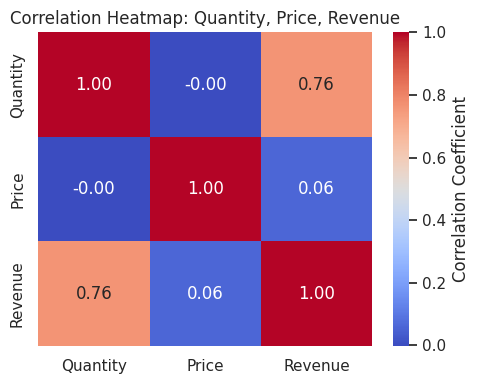

          Quantity     Price   Revenue
Quantity  1.000000 -0.001319  0.762623
Price    -0.001319  1.000000  0.061029
Revenue   0.762623  0.061029  1.000000


In [47]:
# .corr() calculates the correlation coefficient between every pair of numeric columns
# Value ranges from -1 (opposite) to +1 (move together), 0 = no relationship
correlation_matrix = df[['Quantity', 'Price', 'Revenue']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap: Quantity, Price, Revenue')
plt.tight_layout()
plt.show()

print(correlation_matrix)

`Outlier detection with box plots `

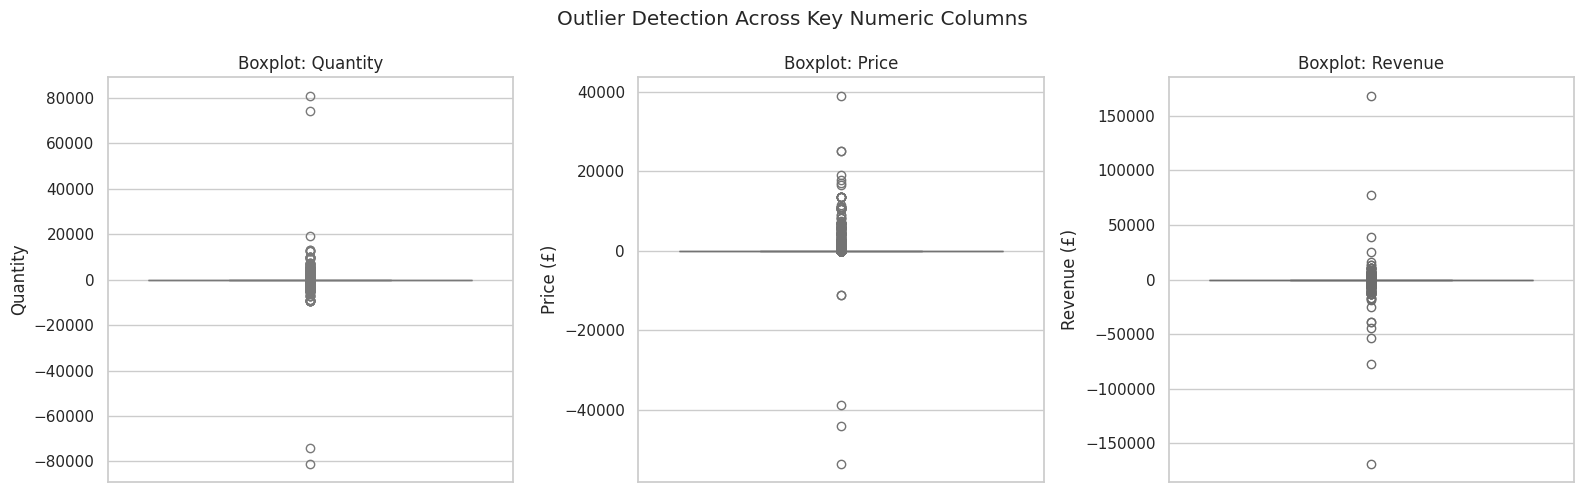

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['Quantity'], ax=axes[0], color='lightblue')
axes[0].set_title('Boxplot: Quantity')
axes[0].set_ylabel('Quantity')

sns.boxplot(y=df['Price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot: Price')
axes[1].set_ylabel('Price (£)')

sns.boxplot(y=df['Revenue'], ax=axes[2], color='salmon')
axes[2].set_title('Boxplot: Revenue')
axes[2].set_ylabel('Revenue (£)')

fig.suptitle('Outlier Detection Across Key Numeric Columns')
plt.tight_layout()
plt.show()

In [49]:
# Quantifying outliers using the IQR method
def count_outliers(column):
    q1 = column.quantile(0.25)   # 25th percentile
    q3 = column.quantile(0.75)   # 75th percentile
    iqr = q3 - q1                # the "middle 50%" spread
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return len(outliers)

for col in ['Quantity', 'Price', 'Revenue']:
    print(f"{col}: {count_outliers(df[col])} outliers detected")

Quantity: 116489 outliers detected
Price: 68105 outliers detected
Revenue: 90922 outliers detected


## Business Insights

1. **UK dominates revenue** — the majority of total revenue comes from United Kingdom customers, showing heavy reliance on the domestic market, compared to all international markets combined. Secondary markets are Ireland and Netherlands.

2. **A small set of products drive most sales** — the top 10 products by quantity differ from the top 10 by revenue, meaning some high-volume items are cheap, while a few pricier items generate outsized revenue.

3. **Sales are seasonal** — the monthly revenue chart shows clear peaks, likely tied to the holiday shopping season (Nov–Dec), suggesting inventory and staffing should scale up ahead of this period.

4. **Missing Customer IDs are a data quality risk** — a notable percentage of transactions have no Customer ID, meaning they can't be linked to a specific buyer, which will limit any future recommendation system.

5. **Returns/cancellations exist in the data** — invoices starting with "C" and negative Quantities and Revenue values represents cancelled orders; these should not be treated as genuine purchase signals in a recommendation model.
And this indicates a need for a return-policy analysis in the next phase.

6. **Outliers exist in Quantity and Price** — some transactions show unusually large quantities or extreme prices, possibly bulk/wholesale orders, or data entry issues which we must investigate before modeling.